In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
TARGET_COLS = ["Dry_Clover_g", "Dry_Dead_g", "Dry_Green_g", "GDM_g", "Dry_Total_g"]
y_train = np.load("../train_targets.npy")
y_pred = np.load("../val_predictions.npy")
y = np.load("../val_targets.npy")

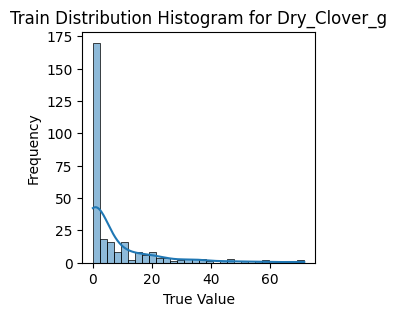

Dry_Clover_g: Median (train) = 0.490
Dry_Clover_g: Fraction zero in train = 0.437
Dry_Clover_g: Fraction zero in val = 0.151


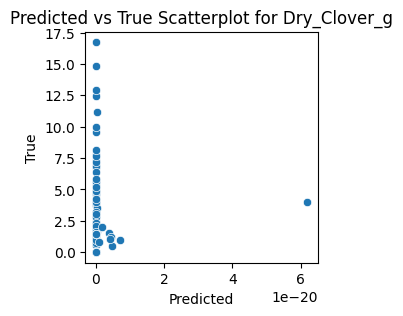

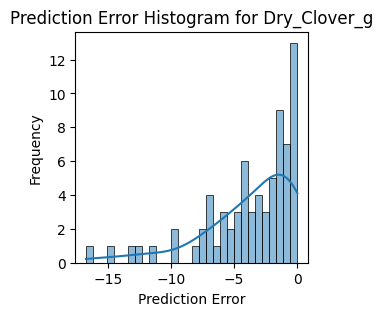

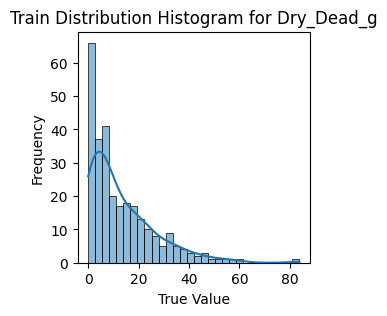

Dry_Dead_g: Median (train) = 8.308
Dry_Dead_g: Fraction zero in train = 0.137
Dry_Dead_g: Fraction zero in val = 0.014


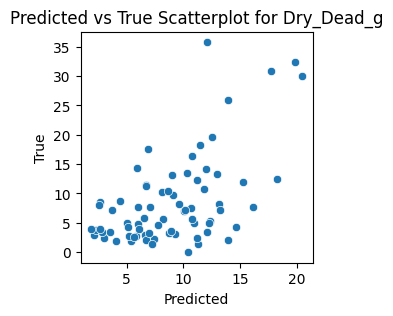

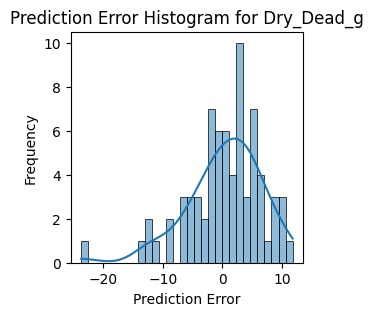

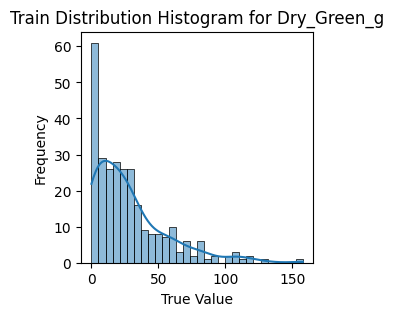

Dry_Green_g: Median (train) = 20.850
Dry_Green_g: Fraction zero in train = 0.063
Dry_Green_g: Fraction zero in val = 0.000


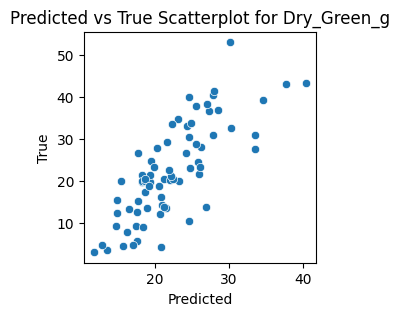

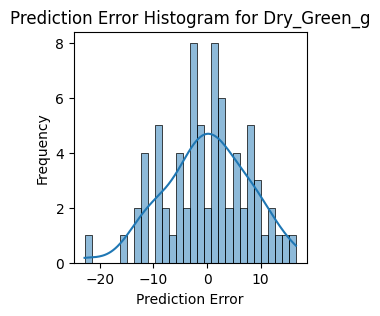

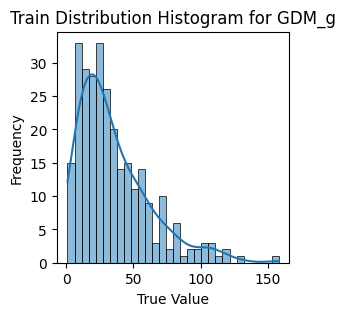

GDM_g: Median (train) = 27.681
GDM_g: Fraction zero in train = 0.000
GDM_g: Fraction zero in val = 0.000


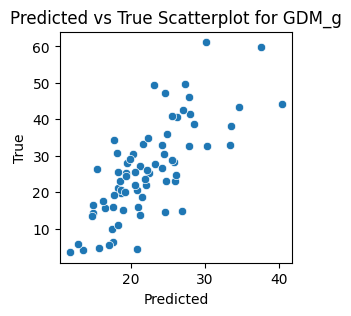

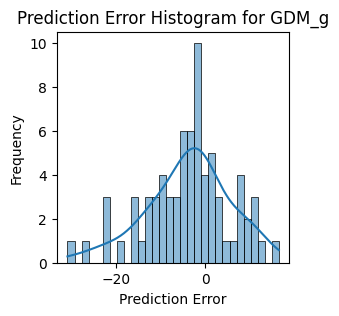

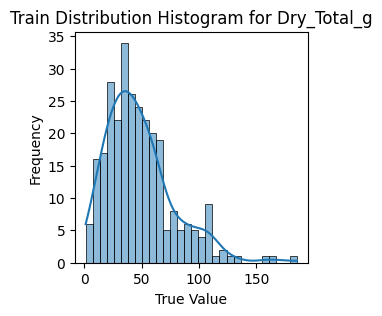

Dry_Total_g: Median (train) = 41.873
Dry_Total_g: Fraction zero in train = 0.000
Dry_Total_g: Fraction zero in val = 0.000


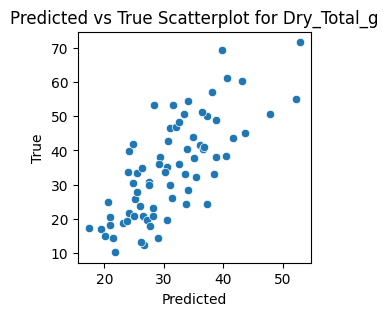

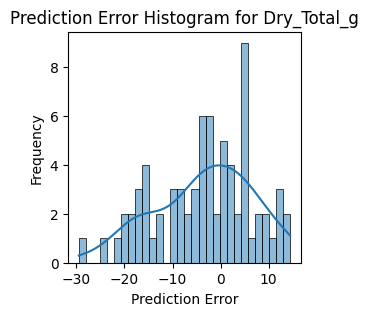

In [9]:


for i in range(y_pred.shape[1]):
    TARGET_INDEX = i
    ytp = y_pred[:, TARGET_INDEX]
    yt = y[:, TARGET_INDEX]

    # Plot histogram of true values for training set for this target
    plt.figure(figsize=(3, 3))
    sns.histplot(y_train[:, TARGET_INDEX], bins=30, kde=True)
    plt.xlabel("True Value")
    plt.ylabel("Frequency")
    plt.title(f"Train Distribution Histogram for {TARGET_COLS[TARGET_INDEX]}")
    plt.show()
    median_train = np.median(y_train[:, TARGET_INDEX])
    print(f"{TARGET_COLS[TARGET_INDEX]}: Median (train) = {median_train:.3f}")

    frac_zero_train = np.sum(y_train[:, TARGET_INDEX] == 0) / len(y_train[:, TARGET_INDEX])
    print(f"{TARGET_COLS[TARGET_INDEX]}: Fraction zero in train = {frac_zero_train:.3f}")
    frac_zero_val = np.sum(yt == 0) / len(yt)
    print(f"{TARGET_COLS[TARGET_INDEX]}: Fraction zero in val = {frac_zero_val:.3f}")

    plt.figure(figsize=(3, 3))
    sns.scatterplot(x=ytp, y=yt)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Predicted vs True Scatterplot for {TARGET_COLS[TARGET_INDEX]}")
    plt.show()

    err = ytp - yt
    # Plot histogram of prediction errors for each target
    plt.figure(figsize=(3, 3))
    sns.histplot(err, bins=30, kde=True)
    plt.xlabel("Prediction Error")
    plt.ylabel("Frequency")
    plt.title(f"Prediction Error Histogram for {TARGET_COLS[TARGET_INDEX]}")
    plt.show()
